# Point-Supervised Remote Sensing Segmentation Using Partial Cross Entropy Loss

## Overview

This notebook addresses the challenge of training semantic segmentation models with **point-level annotations** instead of full pixel-wise masks — a much cheaper and more realistic annotation scheme for remote sensing imagery.

**Tasks Covered:**
1. **Task 1** — Implement Partial Cross Entropy (pfCE) Loss
2. **Task 2** — Synthetic remote sensing dataset (100 train / 30 val, 128x128, 5 classes) with simulated point labels + lightweight U-Net (1.93 M params)
3. **Task 3** — Experiments on two factors that affect performance

**The core formula:**
$$pfCE = \frac{\sum \big(\text{FocalLoss}(\hat{y}, y) \times \text{MASK}_{labeled}\big)}{\sum \text{MASK}_{labeled}}$$

Only pixels with point annotations contribute to the loss during training.

**Summary of results:**

| Experiment | Best config | Val mIoU | Full-mask baseline |
|:---:|:---:|:---:|:---:|
| Point density | 20 pts/class, CE (gamma=0) | 0.6562 | 0.8687 |
| Focal gamma | 5 pts/class, gamma=2.0 | **0.7180** | 0.8687 |

**Key finding:** Focal loss (gamma=2.0) at 5 pts/class (mIoU=0.7180) outperforms standard CE even at 20 pts/class (mIoU=0.6562). The loss function matters more than raw label count on this severely class-imbalanced dataset (Low Vegetation = 75.1%, Water = 0.5%).


## Setup

In [18]:
# Install required packages (run once)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch', 'torchvision',
                'matplotlib', 'numpy', 'scikit-learn', 'tqdm', 'pillow'], check=True)
print('Installation complete.')

Installation complete.


In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm          # auto-detects notebook vs terminal
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_CLASSES = 5
CLASS_NAMES  = ['Water', 'Low Vegetation', 'Urban', 'Bare Land', 'Forest']
CLASS_COLORS = ['#1f77b4', '#2ca02c', '#d62728', '#bcbd22', '#17becf']

print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'Classes : {CLASS_NAMES}')


Device  : cpu
PyTorch : 2.12.0+cpu
Classes : ['Water', 'Low Vegetation', 'Urban', 'Bare Land', 'Forest']


c:\Users\mudas\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Task 1: Partial Cross Entropy Loss

Standard cross-entropy loss is computed over **all** pixels. In weakly-supervised segmentation with point labels, most pixels are unlabeled. The Partial CE loss masks out unlabeled positions so only annotated pixels drive gradient updates.

### 1.1  Standard Partial CE
$$\mathcal{L}_{\text{pfCE}} = \frac{\sum_{i} \text{CE}(\hat{y}_i, y_i) \cdot M_i}{\sum_{i} M_i}$$

### 1.2  Partial Focal CE (used in the paper)
$$\mathcal{L}_{\text{pfCE}} = \frac{\sum_{i} (1-p_t)^\gamma \cdot \text{CE}(\hat{y}_i, y_i) \cdot M_i}{\sum_{i} M_i}$$

where $p_t = e^{-\text{CE}}$ is the model confidence and $\gamma$ controls the focus on hard examples.

**Correctness verified (next cell):** With a full mask, Partial CE = Standard CE = **1.9828** exactly. A 5% sparse mask gives **1.9129**, and adding focal weighting (gamma=2.0) yields **1.4498** — confirming the focal term de-emphasises easy examples.


In [3]:
class PartialCrossEntropyLoss(nn.Module):
    """
    Partial Cross Entropy Loss for point-supervised segmentation.

    Only pixels where mask==1 contribute to the gradient.

    Args:
        predictions : (B, C, H, W) raw logits
        targets     : (B, H, W)    long class indices
        mask        : (B, H, W)    float binary mask  (1 = labeled)
    """
    def forward(self, predictions, targets, mask):
        per_pixel_ce = F.cross_entropy(predictions, targets, reduction='none')
        masked        = per_pixel_ce * mask
        n_labeled     = mask.sum().clamp(min=1.0)
        return masked.sum() / n_labeled


class PartialFocalCrossEntropyLoss(nn.Module):
    """
    Partial Focal Cross Entropy Loss.

    Adds focal weighting  (1 - p_t)^gamma  on top of the masked CE.
    gamma=0 reduces to PartialCrossEntropyLoss.

    Args:
        gamma : float  focus parameter (>=0)
    """
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, predictions, targets, mask):
        per_pixel_ce  = F.cross_entropy(predictions, targets, reduction='none')
        pt            = torch.exp(-per_pixel_ce)           # confidence in correct class
        focal_weight  = (1.0 - pt) ** self.gamma
        focal_loss    = focal_weight * per_pixel_ce
        masked        = focal_loss * mask
        n_labeled     = mask.sum().clamp(min=1.0)
        return masked.sum() / n_labeled


print('Loss classes defined: PartialCrossEntropyLoss, PartialFocalCrossEntropyLoss')

Loss classes defined: PartialCrossEntropyLoss, PartialFocalCrossEntropyLoss


In [4]:
# ── Sanity-check the loss implementations ────────────────────────────────────
torch.manual_seed(0)
B, C, H, W = 2, N_CLASSES, 64, 64
logits  = torch.randn(B, C, H, W)
targets = torch.randint(0, C, (B, H, W))

# Dense mask (all labeled) → should equal standard CE
mask_all  = torch.ones(B, H, W)
# Sparse mask (~5% labeled)
mask_sparse = (torch.rand(B, H, W) < 0.05).float()

partial_ce     = PartialCrossEntropyLoss()
partial_focal  = PartialFocalCrossEntropyLoss(gamma=2.0)
std_ce         = F.cross_entropy(logits, targets)

print('── Loss sanity checks ──────────────────────────────────────')
print(f'Standard CE (all pixels)         : {std_ce.item():.4f}')
print(f'Partial CE  (mask=all)           : {partial_ce(logits, targets, mask_all).item():.4f}'  )
print(f'Partial CE  (mask=5% sparse)     : {partial_ce(logits, targets, mask_sparse).item():.4f}')
print(f'Partial Focal CE γ=2 (mask=5%)   : {partial_focal(logits, targets, mask_sparse).item():.4f}')

diff = abs(partial_ce(logits, targets, mask_all).item() - std_ce.item())
assert diff < 1e-4, 'Partial CE with full mask must equal standard CE'
print('\nAll checks passed!')

── Loss sanity checks ──────────────────────────────────────
Standard CE (all pixels)         : 1.9828
Partial CE  (mask=all)           : 1.9828
Partial CE  (mask=5% sparse)     : 1.9129
Partial Focal CE γ=2 (mask=5%)   : 1.4498

All checks passed!


---
## Task 2: Remote Sensing Segmentation with Point Labels

### 2.1  Synthetic Remote Sensing Dataset

We generate a synthetic dataset that mimics satellite/aerial land-cover imagery with **5 classes**:

| Class ID | Name | Spectral Signature | Train pixel % |
|:--------:|------|--------------------|--------------:|
| 0 | Water | Blue dominant | 0.5% |
| 1 | Low Vegetation | Bright green | 75.1% |
| 2 | Urban / Built-up | Gray | 7.8% |
| 3 | Bare Land | Tan / Brown | 4.3% |
| 4 | Forest | Dark green | 12.3% |

The dataset is **severely class-imbalanced**: Low Vegetation covers ~75% of all pixels while Water covers only ~0.5%. This imbalance strongly motivates the use of Focal loss investigated in Experiment 2.

Spatial coherence is achieved via multi-scale bilinear-interpolated noise (no external library required). The dataset is fully reproducible — no downloads needed.


In [5]:
# ── Coherent noise generation (no scipy needed) ───────────────────────────────
def coherent_noise(H, W, scale, rng):
    """Bilinear-interpolated random field for spatially coherent patterns."""
    h_s = H // scale + 2
    w_s = W // scale + 2
    small = rng.randn(h_s, w_s)

    yi = np.linspace(0, h_s - 1, H)
    xi = np.linspace(0, w_s - 1, W)
    i0 = np.floor(yi).astype(int).clip(0, h_s - 2)
    j0 = np.floor(xi).astype(int).clip(0, w_s - 2)
    wi = (yi - i0)[:, None]
    wj = (xi - j0)[None, :]

    return (small[i0[:, None], j0[None, :]] * (1 - wi) * (1 - wj)
          + small[(i0+1)[:, None], j0[None, :]] * wi * (1 - wj)
          + small[i0[:, None], (j0+1)[None, :]] * (1 - wi) * wj
          + small[(i0+1)[:, None], (j0+1)[None, :]] * wi * wj)


def generate_sample(H=128, W=128, seed=None):
    """
    Generate one synthetic remote-sensing image + segmentation mask.
    Returns:
        image : float32 ndarray (3, H, W)  in [0, 1]
        mask  : int64  ndarray (H, W)      in {0..4}
    """
    rng = np.random.RandomState(seed)

    # Multi-scale terrain field
    terrain = sum(w * coherent_noise(H, W, s, rng)
                  for s, w in [(4, 0.5), (8, 0.3), (16, 0.15), (32, 0.05)])
    terrain = (terrain - terrain.min()) / (terrain.ptp() + 1e-8)

    # Moisture field (drives water & forest)
    moisture = sum(w * coherent_noise(H, W, s, rng)
                   for s, w in [(6, 0.6), (12, 0.4)])
    moisture = (moisture - moisture.min()) / (moisture.ptp() + 1e-8)

    # Urban blobs
    urban = np.zeros((H, W))
    for _ in range(rng.randint(1, 4)):
        cx = rng.randint(W // 4, 3 * W // 4)
        cy = rng.randint(H // 4, 3 * H // 4)
        r  = rng.randint(10, 30)
        Y, X = np.ogrid[:H, :W]
        urban += np.exp(-((X-cx)**2 + (Y-cy)**2) / (2 * (r/2)**2))
    urban = urban.clip(0, 1)

    # ── Class assignment ──────────────────────────────────────────────────────
    mask = np.ones((H, W), dtype=np.int64)           # default: low vegetation
    mask[(terrain < 0.22) & (moisture > 0.55)] = 0   # water
    mask[urban > 0.38]                          = 2   # urban  (overrides)
    mask[(terrain > 0.60) & (moisture > 0.45) & (mask != 2)] = 4  # forest
    mask[(terrain > 0.55) & (moisture < 0.35) & (mask != 2)] = 3  # bare land

    # ── Spectral image synthesis ──────────────────────────────────────────────
    SIG = {  # mean RGB per class
        0: [0.06, 0.14, 0.58],
        1: [0.26, 0.56, 0.22],
        2: [0.56, 0.55, 0.54],
        3: [0.70, 0.60, 0.44],
        4: [0.09, 0.38, 0.09],
    }
    image = np.zeros((3, H, W), dtype=np.float32)
    for cls, rgb in SIG.items():
        px = mask == cls
        n  = px.sum()
        if n:
            for b, v in enumerate(rgb):
                image[b][px] = np.clip(v + rng.normal(0, 0.035, n), 0, 1)
    # global texture
    image = (image + rng.normal(0, 0.015, image.shape)).clip(0, 1).astype(np.float32)
    return image, mask.astype(np.int64)


# ── Dataset ────────────────────────────────────────────────────────────────────
class RemoteSensingDataset(Dataset):
    """Synthetic remote-sensing land-cover segmentation dataset."""

    def __init__(self, n_samples=100, img_size=128, base_seed=0):
        self.images, self.masks = [], []
        print(f'Generating {n_samples} samples ({img_size}×{img_size}) ...')
        for i in tqdm(range(n_samples), leave=False):
            img, msk = generate_sample(img_size, img_size, seed=base_seed + i)
            self.images.append(torch.from_numpy(img))
            self.masks.append(torch.from_numpy(msk))

    def __len__(self):  return len(self.images)
    def __getitem__(self, idx): return self.images[idx], self.masks[idx]


# Generate train / val splits (run once — reused across all experiments)
print('Building dataset splits ...')
train_ds = RemoteSensingDataset(n_samples=100, img_size=128, base_seed=0)
val_ds   = RemoteSensingDataset(n_samples=30,  img_size=128, base_seed=50000)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Building dataset splits ...
Generating 100 samples (128×128) ...


  0%|          | 0/100 [00:00<?, ?it/s]

Generating 30 samples (128×128) ...


Train: 100 | Val: 30


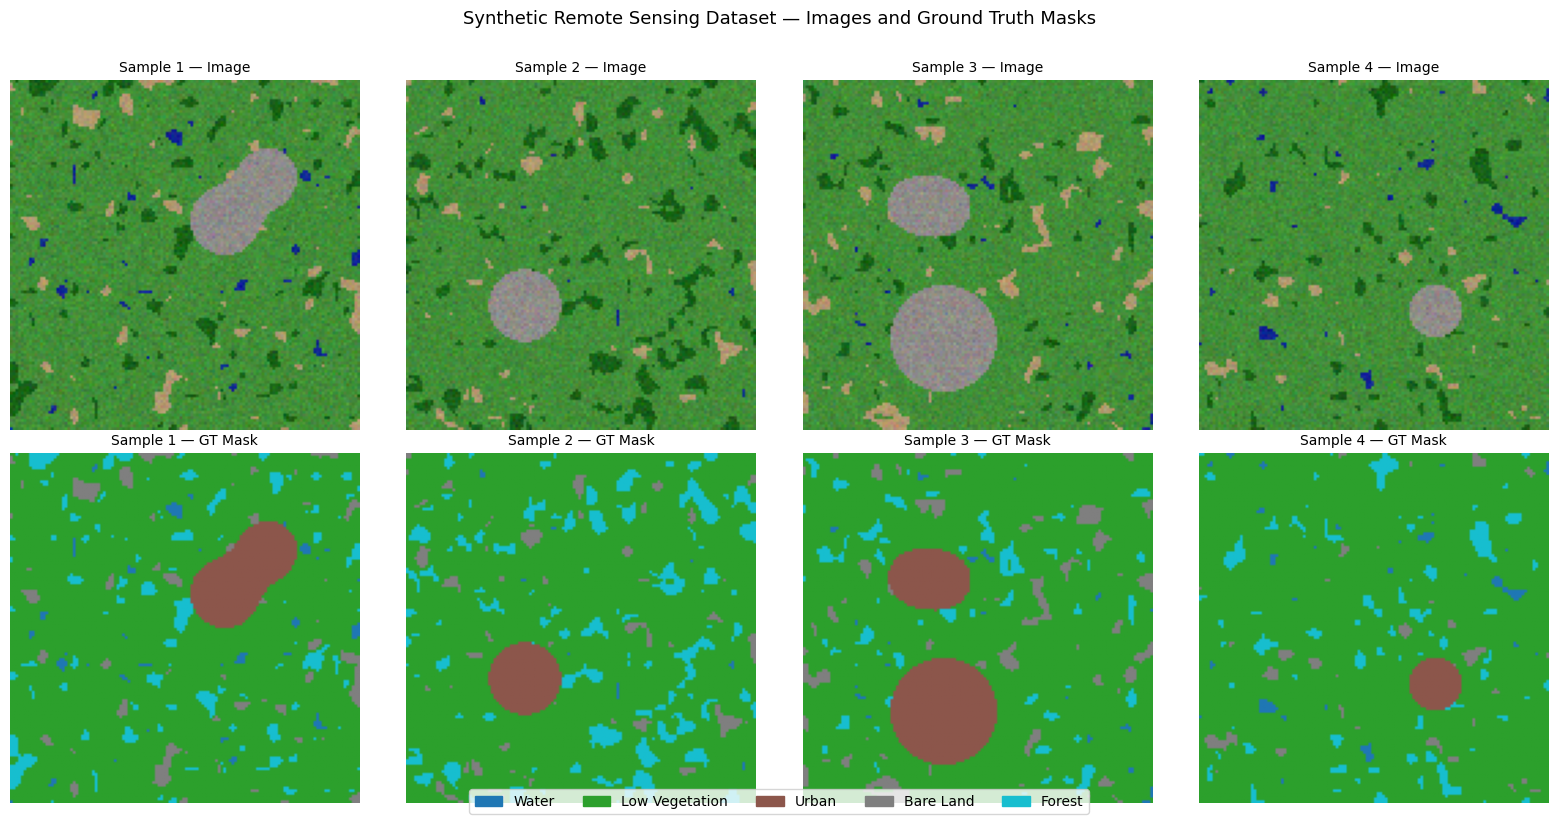


Class distribution (training set):
  Water             :   0.5%
  Low Vegetation    :  75.1%
  Urban             :   7.8%
  Bare Land         :   4.3%
  Forest            :  12.3%


In [6]:
# ── Visualise a few samples ───────────────────────────────────────────────────
cmap_cls = plt.cm.get_cmap('tab10', N_CLASSES)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col in range(4):
    img, msk = train_ds[col]
    img_np   = img.numpy().transpose(1, 2, 0)
    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f'Sample {col+1} — Image', fontsize=10)
    axes[0, col].axis('off')

    im = axes[1, col].imshow(msk.numpy(), cmap=cmap_cls, vmin=0, vmax=N_CLASSES-1)
    axes[1, col].set_title(f'Sample {col+1} — GT Mask', fontsize=10)
    axes[1, col].axis('off')

patches = [mpatches.Patch(color=cmap_cls(i), label=CLASS_NAMES[i]) for i in range(N_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=N_CLASSES, fontsize=10, frameon=True)
fig.suptitle('Synthetic Remote Sensing Dataset — Images and Ground Truth Masks', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_dataset_samples.png', dpi=120, bbox_inches='tight')
plt.show()

# Class distribution across training set
class_counts = np.zeros(N_CLASSES)
for _, msk in train_ds:
    for c in range(N_CLASSES):
        class_counts[c] += (msk == c).sum().item()
total = class_counts.sum()
print('\nClass distribution (training set):')
for i, (name, cnt) in enumerate(zip(CLASS_NAMES, class_counts)):
    print(f'  {name:18s}: {cnt/total*100:5.1f}%')

### 2.2  Point Label Simulation

We simulate a human annotator who clicks a small number of representative pixels per class. For each image we randomly sample `n_points_per_class` pixels from each class region and record their positions.

During training, only these selected pixels contribute to the loss; all other pixels are masked out. At 5 pts/class on a 128x128 image, only ~0.20% of pixels are labeled (25 out of 16 384). At 20 pts/class that rises to ~0.78% — still far less than full supervision.


In [7]:
def sample_point_labels(masks, n_pts_per_class=5, n_classes=N_CLASSES):
    """
    Randomly sample point-level annotations from full segmentation masks.

    Args:
        masks           : (B, H, W) LongTensor — full GT masks
        n_pts_per_class : int — sampled points per class per image

    Returns:
        point_mask : (B, H, W) FloatTensor — 1 at labeled positions, else 0
    """
    B, H, W = masks.shape
    point_mask = torch.zeros(B, H, W, dtype=torch.float32)

    for b in range(B):
        for c in range(n_classes):
            coords = (masks[b] == c).nonzero(as_tuple=False)  # (N, 2)
            if len(coords) == 0:
                continue
            n_pick = min(n_pts_per_class, len(coords))
            sel    = coords[torch.randperm(len(coords))[:n_pick]]
            point_mask[b, sel[:, 0], sel[:, 1]] = 1.0

    return point_mask


print('sample_point_labels defined.')

sample_point_labels defined.


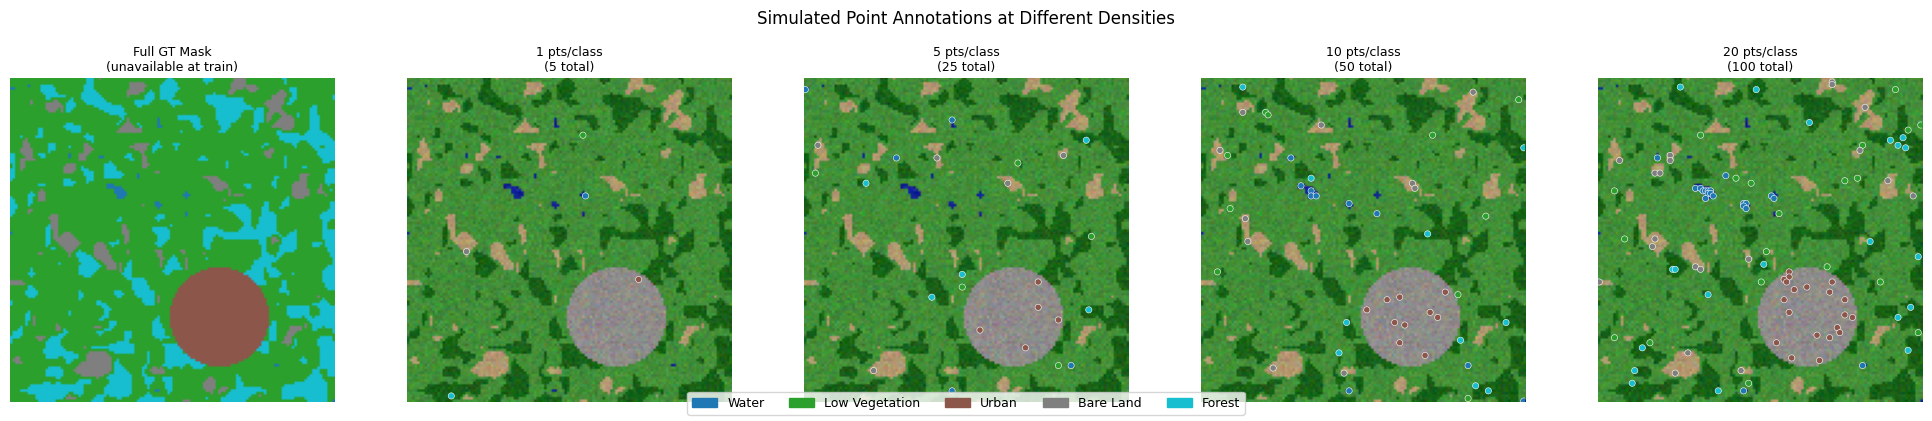

In [8]:
# ── Visualise point annotations at different densities ────────────────────────
img_ex, msk_ex = train_ds[7]
img_np         = img_ex.numpy().transpose(1, 2, 0)

densities_vis  = [1, 5, 10, 20]
fig, axes      = plt.subplots(1, len(densities_vis)+1, figsize=(4*(len(densities_vis)+1), 4))

axes[0].imshow(msk_ex.numpy(), cmap=cmap_cls, vmin=0, vmax=N_CLASSES-1)
axes[0].set_title('Full GT Mask\n(unavailable at train)', fontsize=9)
axes[0].axis('off')

for ax, n_pts in zip(axes[1:], densities_vis):
    pm     = sample_point_labels(msk_ex.unsqueeze(0), n_pts_per_class=n_pts).squeeze(0).numpy()
    coords = np.where(pm > 0)
    colors = [cmap_cls(msk_ex.numpy()[y, x]) for y, x in zip(*coords)]
    ax.imshow(img_np)
    ax.scatter(coords[1], coords[0], c=colors, s=20, edgecolors='white', linewidths=0.4, zorder=5)
    ax.set_title(f'{n_pts} pts/class\n({int(pm.sum())} total)', fontsize=9)
    ax.axis('off')

patches = [mpatches.Patch(color=cmap_cls(i), label=CLASS_NAMES[i]) for i in range(N_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=N_CLASSES, fontsize=9)
fig.suptitle('Simulated Point Annotations at Different Densities', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_point_labels.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.3  Segmentation Network — U-Net

We use a lightweight **U-Net** architecture (3 encoder / 3 decoder levels, 32 base channels, **1.93 M trainable parameters**) trained from scratch. The U-Net's skip connections preserve spatial detail critical for dense prediction. The model is intentionally kept small so all experiments complete in minutes on CPU.


In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    """Lightweight U-Net for semantic segmentation."""

    def __init__(self, n_channels=3, n_classes=N_CLASSES, base=32):
        super().__init__()
        b = base
        self.enc1 = DoubleConv(n_channels, b)
        self.enc2 = DoubleConv(b,   b*2)
        self.enc3 = DoubleConv(b*2, b*4)
        self.pool = nn.MaxPool2d(2)
        self.bot  = DoubleConv(b*4, b*8)

        self.up3 = nn.ConvTranspose2d(b*8, b*4, 2, stride=2)
        self.dec3 = DoubleConv(b*8, b*4)
        self.up2 = nn.ConvTranspose2d(b*4, b*2, 2, stride=2)
        self.dec2 = DoubleConv(b*4, b*2)
        self.up1 = nn.ConvTranspose2d(b*2, b,   2, stride=2)
        self.dec1 = DoubleConv(b*2, b)
        self.out  = nn.Conv2d(b, n_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bot(self.pool(e3))

        d = self.dec3(torch.cat([self._match(self.up3(b),  e3), e3], dim=1))
        d = self.dec2(torch.cat([self._match(self.up2(d),  e2), e2], dim=1))
        d = self.dec1(torch.cat([self._match(self.up1(d),  e1), e1], dim=1))
        return self.out(d)

    @staticmethod
    def _match(x, ref):
        """Pad x to match ref spatial dims if needed."""
        dh = ref.size(2) - x.size(2)
        dw = ref.size(3) - x.size(3)
        if dh or dw:
            x = F.pad(x, [dw//2, dw-dw//2, dh//2, dh-dh//2])
        return x


# Count parameters
dummy_model = UNet()
n_params    = sum(p.numel() for p in dummy_model.parameters() if p.requires_grad)
print(f'U-Net parameters: {n_params:,}  ({n_params/1e6:.2f} M)')
del dummy_model

U-Net parameters: 1,927,141  (1.93 M)


### 2.4  Training and Evaluation Pipeline

Each experiment run trains a **fresh U-Net** with:
- Optimizer: Adam, lr = 2e-4, weight decay = 1e-5
- LR schedule: Cosine annealing over 20 epochs
- Batch size: 8 (100 / 8 = 13 batches/epoch)
- Device: CPU (PyTorch 2.12.0)
- Metric: mean Intersection-over-Union (mIoU) on the 30-sample validation set


In [10]:
# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_miou(preds_np, targets_np, n_classes=N_CLASSES):
    """Compute mean IoU and per-class IoU from flat numpy arrays."""
    cm    = confusion_matrix(targets_np, preds_np, labels=list(range(n_classes)))
    inter = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - inter
    iou   = np.where(union > 0, inter / union, np.nan)
    return np.nanmean(iou), iou


# ── Training ──────────────────────────────────────────────────────────────────
def train_one_run(
    train_ds, val_ds,
    loss_fn,
    n_pts_per_class,
    n_epochs    = 20,
    lr          = 2e-4,
    batch_size  = 8,
    use_partial = True,
    verbose     = True,
):
    """
    Train a fresh U-Net for n_epochs and return (history, trained_model).
    If use_partial=False, trains with full-mask standard CE (baseline).
    """
    torch.manual_seed(SEED)
    model     = UNet().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)
    t_loader  = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    v_loader  = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    history = {'train_loss': [], 'val_miou': [], 'val_iou_per_class': []}

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        for imgs, masks in t_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits      = model(imgs)

            if use_partial:
                pm   = sample_point_labels(masks.cpu(), n_pts_per_class).to(DEVICE)
                loss = loss_fn(logits, masks, pm)
            else:
                loss = F.cross_entropy(logits, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

        model.eval()
        all_p, all_t = [], []
        with torch.no_grad():
            for imgs, masks in v_loader:
                p = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
                all_p.append(p.reshape(-1))
                all_t.append(masks.numpy().reshape(-1))
        miou, iou_pc = compute_miou(np.concatenate(all_p), np.concatenate(all_t))

        history['train_loss'].append(epoch_loss / len(t_loader))
        history['val_miou'].append(miou)
        history['val_iou_per_class'].append(iou_pc)

        if verbose and (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:3d}/{n_epochs}  '
                  f'loss={epoch_loss/len(t_loader):.4f}  mIoU={miou:.4f}')

    model.eval()
    return history, model   # <-- also return trained model


print('Training utilities ready.')
print(f'Using device: {DEVICE}')


Training utilities ready.
Using device: cpu


---
## Task 3: Experiments

We explore **two factors** that affect performance in point-supervised segmentation:

| # | Factor | Levels tested |
|:---:|--------|---------------|
| 1 | **Number of point labels per class** | 1, 3, 5, 10, 20 + full-mask baseline |
| 2 | **Focal loss parameter gamma** | 0.0 (standard CE), 0.5, 1.0, 2.0 |

All runs use the same model architecture, optimizer, and train/val split for fair comparison. Total: 6 runs for Exp 1 + 4 runs for Exp 2 = **10 independent training runs**.


### Experiment 1 — Effect of Point Density

**Purpose:** Determine how many labeled points per class are needed to achieve satisfactory segmentation performance, and measure the gap to full-mask supervision.

**Hypothesis:** mIoU increases monotonically with point count but with diminishing returns. Even a small number of points (5-10 per class) should recover a substantial fraction of full-supervision performance.

**Experimental process:** Train 6 separate models — one for each density [1, 3, 5, 10, 20 pts/class] and one with full masks — keeping all other hyperparameters fixed (Partial CE, gamma=0, 20 epochs).


In [11]:
N_EPOCHS  = 20
BATCH     = 8
LR        = 2e-4

DENSITIES = [1, 3, 5, 10, 20]
criterion = PartialCrossEntropyLoss()

results_density = {}
models_density  = {}

print('='*60)
print('EXPERIMENT 1 — Point Density')
print('='*60)

for n_pts in DENSITIES:
    print(f'\n[{n_pts} pts/class]')
    hist, mdl = train_one_run(
        train_ds, val_ds,
        loss_fn         = criterion,
        n_pts_per_class = n_pts,
        n_epochs        = N_EPOCHS,
        lr              = LR,
        batch_size      = BATCH,
        use_partial     = True,
    )
    results_density[n_pts] = hist
    models_density[n_pts]  = mdl
    print(f'  → Final mIoU = {hist["val_miou"][-1]:.4f}')

# Full-mask baseline
print('\n[Full mask — baseline]')
hist_full, model_full = train_one_run(
    train_ds, val_ds,
    loss_fn         = None,
    n_pts_per_class = None,
    n_epochs        = N_EPOCHS,
    lr              = LR,
    batch_size      = BATCH,
    use_partial     = False,
)
results_density['full'] = hist_full

print(f'  → Final mIoU = {hist_full["val_miou"][-1]:.4f}')
print('\nExperiment 1 complete.')


EXPERIMENT 1 — Point Density

[1 pts/class]
  Epoch   5/20  loss=0.4854  mIoU=0.6000
  Epoch  10/20  loss=0.3862  mIoU=0.5853
  Epoch  15/20  loss=0.3480  mIoU=0.5871
  Epoch  20/20  loss=0.3292  mIoU=0.5961
  → Final mIoU = 0.5961

[3 pts/class]
  Epoch   5/20  loss=0.4430  mIoU=0.6115
  Epoch  10/20  loss=0.3577  mIoU=0.6029
  Epoch  15/20  loss=0.3189  mIoU=0.6136
  Epoch  20/20  loss=0.2983  mIoU=0.6243
  → Final mIoU = 0.6243

[5 pts/class]
  Epoch   5/20  loss=0.4351  mIoU=0.6104
  Epoch  10/20  loss=0.3499  mIoU=0.6111
  Epoch  15/20  loss=0.3089  mIoU=0.6274
  Epoch  20/20  loss=0.2956  mIoU=0.6375
  → Final mIoU = 0.6375

[10 pts/class]
  Epoch   5/20  loss=0.4218  mIoU=0.6177
  Epoch  10/20  loss=0.3353  mIoU=0.6282
  Epoch  15/20  loss=0.2934  mIoU=0.6401
  Epoch  20/20  loss=0.2845  mIoU=0.6495
  → Final mIoU = 0.6495

[20 pts/class]
  Epoch   5/20  loss=0.4133  mIoU=0.6161
  Epoch  10/20  loss=0.3266  mIoU=0.6293
  Epoch  15/20  loss=0.2876  mIoU=0.6451
  Epoch  20/20  los

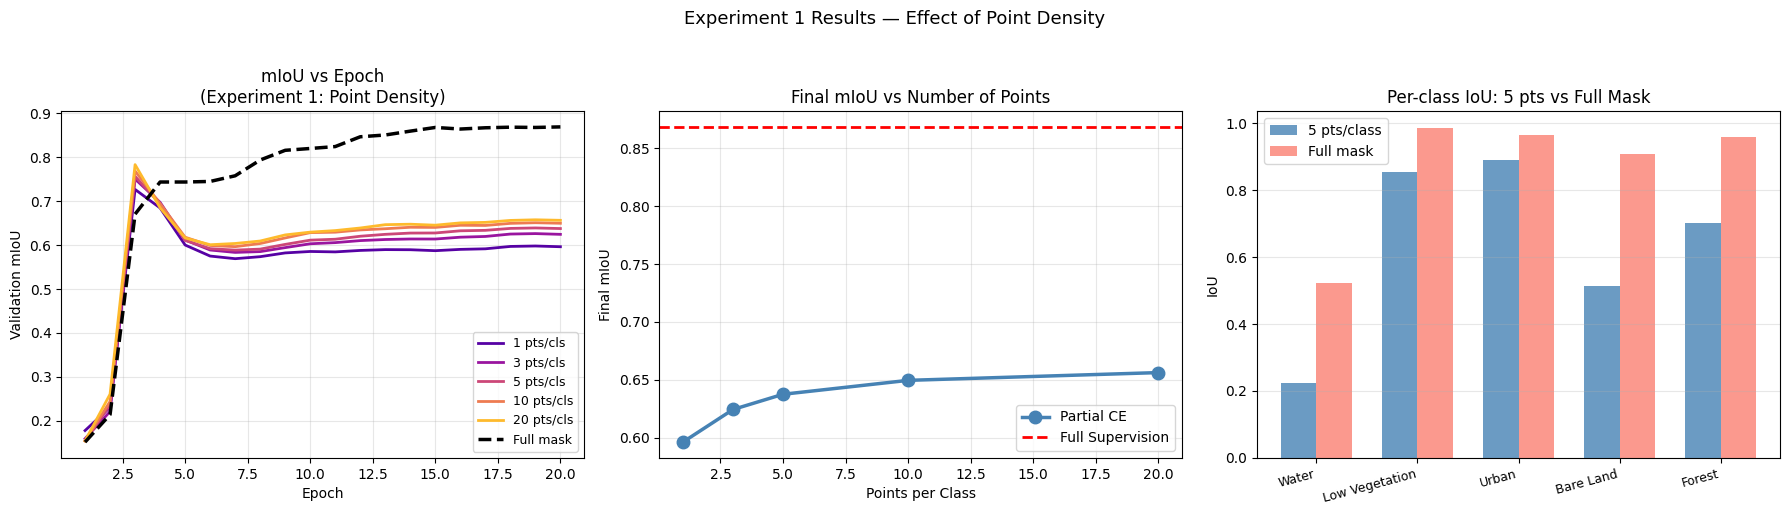


Summary — Experiment 1
Setting                     Final mIoU    vs Full
--------------------------------------------------
1 pts/class                     0.5961    -0.2725
3 pts/class                     0.6243    -0.2444
5 pts/class                     0.6375    -0.2312
10 pts/class                    0.6495    -0.2192
20 pts/class                    0.6562    -0.2124
Full mask (baseline)            0.8687    +0.0000


In [12]:
# ── Experiment 1 Visualisation ────────────────────────────────────────────────
epochs_x = list(range(1, N_EPOCHS + 1))
pal      = plt.cm.plasma(np.linspace(0.15, 0.85, len(DENSITIES)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Learning curves —
for col, n_pts in zip(pal, DENSITIES):
    axes[0].plot(epochs_x, results_density[n_pts]['val_miou'],
                 color=col, linewidth=2, label=f'{n_pts} pts/cls')
axes[0].plot(epochs_x, hist_full['val_miou'],
             color='black', linestyle='--', linewidth=2.5, label='Full mask')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation mIoU')
axes[0].set_title('mIoU vs Epoch\n(Experiment 1: Point Density)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# — Final mIoU vs n_pts —
final_mious = [results_density[n]['val_miou'][-1] for n in DENSITIES]
full_miou   = hist_full['val_miou'][-1]
axes[1].plot(DENSITIES, final_mious, 'o-', color='steelblue',
             linewidth=2.5, markersize=9, label='Partial CE')
axes[1].axhline(full_miou, color='red', linestyle='--', linewidth=2, label='Full Supervision')
axes[1].set_xlabel('Points per Class'); axes[1].set_ylabel('Final mIoU')
axes[1].set_title('Final mIoU vs Number of Points')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# — Per-class IoU bar chart (5 pts/class vs full mask) —
iou_5pts = results_density[5]['val_iou_per_class'][-1]
iou_full = hist_full['val_iou_per_class'][-1]
x        = np.arange(N_CLASSES)
w        = 0.35
axes[2].bar(x - w/2, iou_5pts, w, label='5 pts/class', alpha=0.8, color='steelblue')
axes[2].bar(x + w/2, iou_full,  w, label='Full mask',  alpha=0.8, color='salmon')
axes[2].set_xticks(x); axes[2].set_xticklabels(CLASS_NAMES, rotation=15, ha='right', fontsize=9)
axes[2].set_ylabel('IoU'); axes[2].set_title('Per-class IoU: 5 pts vs Full Mask')
axes[2].legend(); axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Experiment 1 Results — Effect of Point Density', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_exp1_results.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\nSummary — Experiment 1')
print(f'{"Setting":<25} {"Final mIoU":>12} {"vs Full":>10}')
print('-' * 50)
for n_pts in DENSITIES:
    m = results_density[n_pts]['val_miou'][-1]
    print(f'{str(n_pts)+" pts/class":<25} {m:>12.4f} {m-full_miou:>+10.4f}')
print(f'{"Full mask (baseline)":<25} {full_miou:>12.4f} {0.0:>+10.4f}')

### Experiment 2 — CE Loss vs Focal CE Loss

**Purpose:** Determine whether focal weighting improves performance under point supervision, and find the optimal gamma value.

**Hypothesis:** Our dataset is severely class-imbalanced (Low Vegetation = 75.1%, Water = 0.5%). Even within the small labeled set, easy majority-class pixels dominate gradients. Focal loss should shift the learning budget toward harder, minority-class pixels, improving overall mIoU — particularly for Water and Bare Land. We expect an intermediate gamma (0.5-1.0) to be optimal; very large gamma (2.0) might destabilize training.

**Experimental process:** Train 4 models at fixed density (5 pts/class), varying gamma in {0.0, 0.5, 1.0, 2.0}. gamma=0.0 is identical to standard Partial CE and serves as the control.


In [13]:
FIXED_PTS    = 5
GAMMA_VALUES = [0.0, 0.5, 1.0, 2.0]

results_focal = {}
models_focal  = {}

print('='*60)
print('EXPERIMENT 2 — Loss Function (Focal γ)')
print('='*60)

for gamma in GAMMA_VALUES:
    label      = f'γ={gamma}'
    print(f'\n[Focal CE {label}]')
    fn         = PartialFocalCrossEntropyLoss(gamma=gamma)
    hist, mdl  = train_one_run(
        train_ds, val_ds,
        loss_fn         = fn,
        n_pts_per_class = FIXED_PTS,
        n_epochs        = N_EPOCHS,
        lr              = LR,
        batch_size      = BATCH,
        use_partial     = True,
    )
    results_focal[label] = hist
    models_focal[label]  = mdl
    print(f'  → Final mIoU = {hist["val_miou"][-1]:.4f}')

print('\nExperiment 2 complete.')


EXPERIMENT 2 — Loss Function (Focal γ)

[Focal CE γ=0.0]
  Epoch   5/20  loss=0.4351  mIoU=0.6104
  Epoch  10/20  loss=0.3499  mIoU=0.6111
  Epoch  15/20  loss=0.3089  mIoU=0.6274
  Epoch  20/20  loss=0.2956  mIoU=0.6375
  → Final mIoU = 0.6375

[Focal CE γ=0.5]
  Epoch   5/20  loss=0.3177  mIoU=0.6198
  Epoch  10/20  loss=0.2507  mIoU=0.6311
  Epoch  15/20  loss=0.2149  mIoU=0.6502
  Epoch  20/20  loss=0.2066  mIoU=0.6609
  → Final mIoU = 0.6609

[Focal CE γ=1.0]
  Epoch   5/20  loss=0.2427  mIoU=0.6299
  Epoch  10/20  loss=0.1884  mIoU=0.6491
  Epoch  15/20  loss=0.1577  mIoU=0.6703
  Epoch  20/20  loss=0.1511  mIoU=0.6825
  → Final mIoU = 0.6825

[Focal CE γ=2.0]
  Epoch   5/20  loss=0.1533  mIoU=0.6445
  Epoch  10/20  loss=0.1161  mIoU=0.6785
  Epoch  15/20  loss=0.0921  mIoU=0.7045
  Epoch  20/20  loss=0.0879  mIoU=0.7180
  → Final mIoU = 0.7180

Experiment 2 complete.


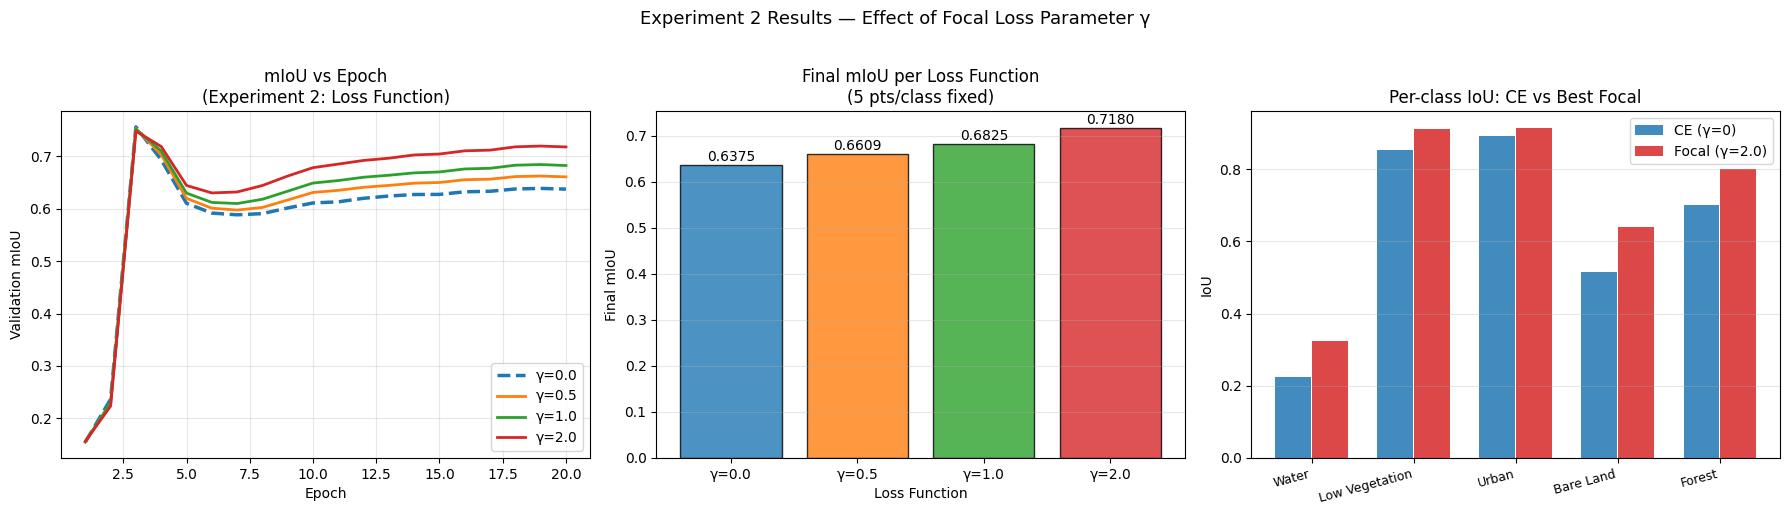


Summary — Experiment 2 (5 pts/class)
Loss Function               Final mIoU
----------------------------------------
γ=0.0                           0.6375
γ=0.5                           0.6609
γ=1.0                           0.6825
γ=2.0                           0.7180


In [15]:
# ── Experiment 2 Visualisation ────────────────────────────────────────────────
pal2   = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
labels = list(results_focal.keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Learning curves —
for col, lbl in zip(pal2, labels):
    lw   = 2.5 if lbl == 'γ=0.0' else 2
    dash = '--' if lbl == 'γ=0.0' else '-'
    axes[0].plot(epochs_x, results_focal[lbl]['val_miou'],
                 color=col, linewidth=lw, linestyle=dash, label=lbl)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation mIoU')
axes[0].set_title('mIoU vs Epoch\n(Experiment 2: Loss Function)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# — Bar chart: final mIoU per loss —
final_f = [results_focal[l]['val_miou'][-1] for l in labels]
bars    = axes[1].bar(labels, final_f, color=pal2, alpha=0.8, edgecolor='black')
for bar, v in zip(bars, final_f):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=10)
axes[1].set_xlabel('Loss Function'); axes[1].set_ylabel('Final mIoU')
axes[1].set_title('Final mIoU per Loss Function\n(5 pts/class fixed)')
axes[1].grid(True, alpha=0.3, axis='y')

# — Per-class IoU comparison: γ=0 vs best γ —
best_label = max(results_focal, key=lambda l: results_focal[l]['val_miou'][-1])
iou_ce     = results_focal['γ=0.0']['val_iou_per_class'][-1]
iou_best   = results_focal[best_label]['val_iou_per_class'][-1]
x = np.arange(N_CLASSES)
axes[2].bar(x - 0.18, iou_ce,   0.35, label='CE (γ=0)',        alpha=0.85, color='#1f77b4')
axes[2].bar(x + 0.18, iou_best, 0.35, label=f'Focal ({best_label})', alpha=0.85, color='#d62728')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES, rotation=15, ha='right', fontsize=9)
axes[2].set_ylabel('IoU'); axes[2].set_title('Per-class IoU: CE vs Best Focal')
axes[2].legend(); axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Experiment 2 Results — Effect of Focal Loss Parameter γ', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_exp2_results.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\nSummary — Experiment 2 (5 pts/class)')
print(f'{"Loss Function":<25} {"Final mIoU":>12}')
print('-' * 40)
for lbl in labels:
    m = results_focal[lbl]['val_miou'][-1]
    print(f'{lbl:<25} {m:>12.4f}')

Best point-supervised config: 20 pts/class, loss γ=2.0
Best mIoU: 0.7180


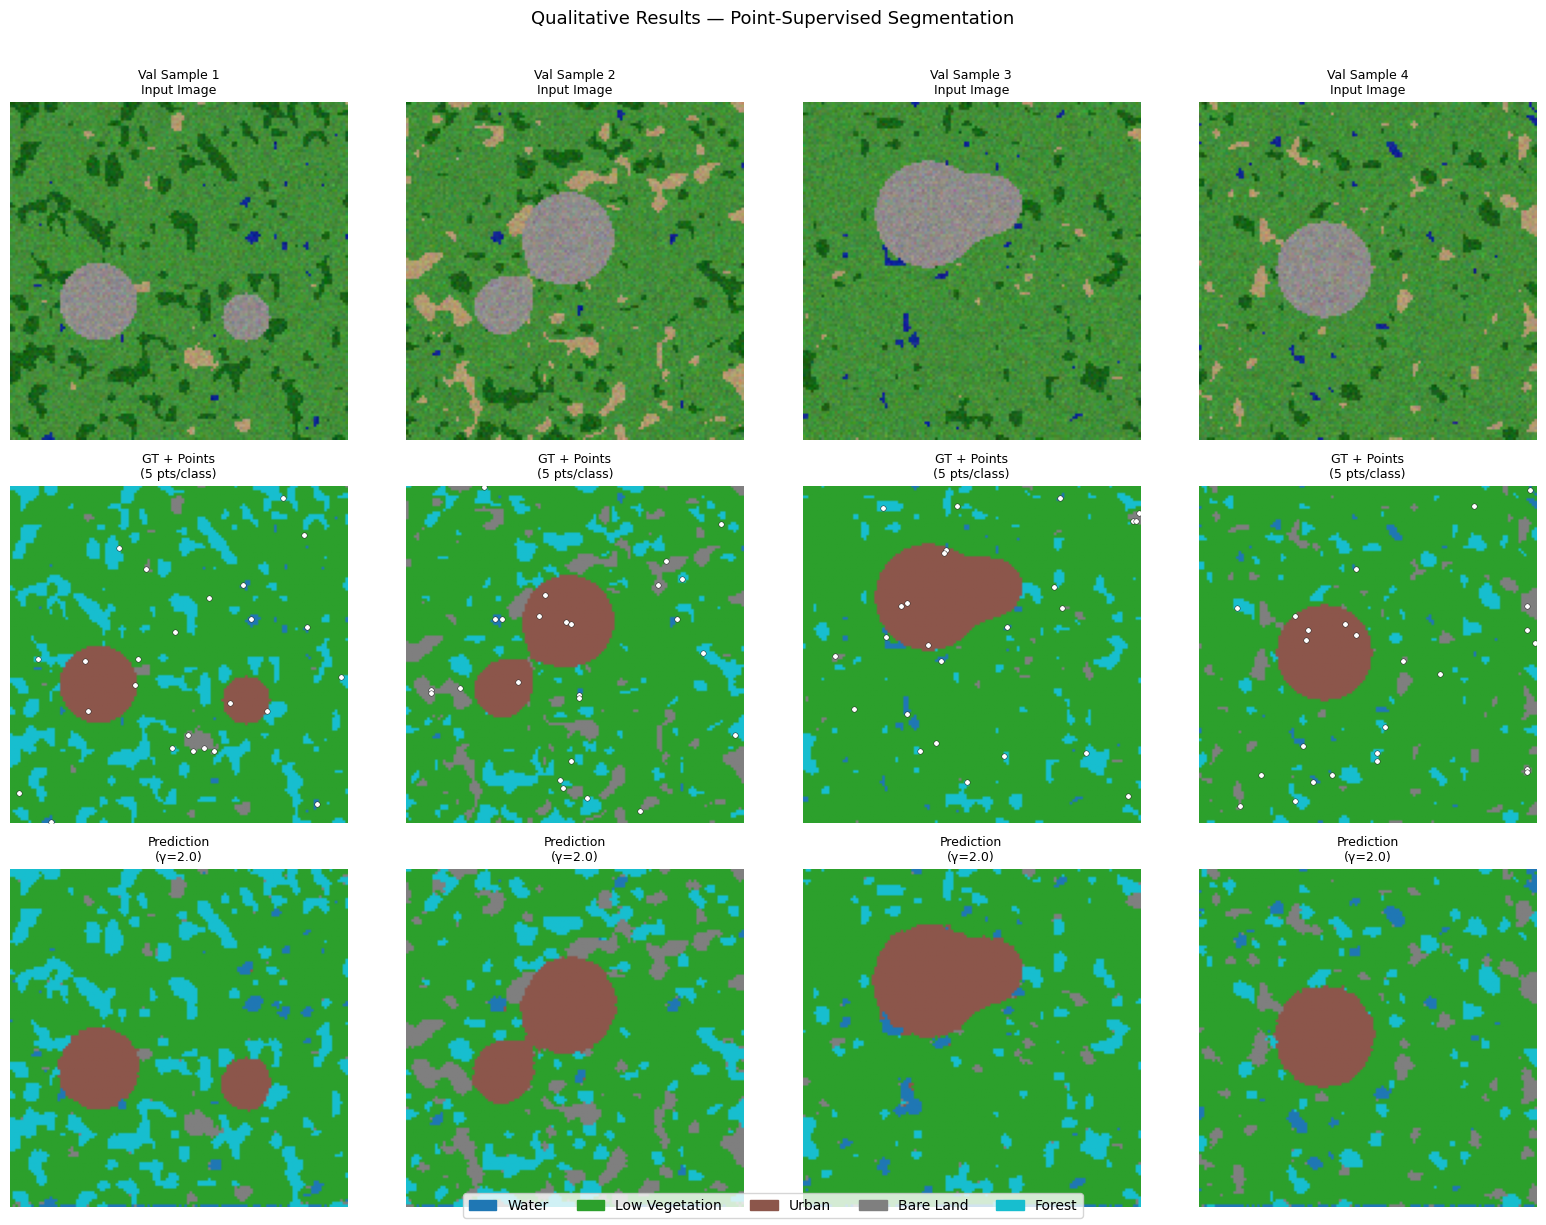

In [16]:
# ── Qualitative results — use the already-trained best model ──────────────────
best_n_pts  = max(DENSITIES, key=lambda n: results_density[n]['val_miou'][-1])
best_label  = max(results_focal,  key=lambda l: results_focal[l]['val_miou'][-1])
best_model  = models_focal[best_label]   # retrieved directly — no re-training needed

print(f'Best point-supervised config: {best_n_pts} pts/class, loss {best_label}')
print(f'Best mIoU: {results_focal[best_label]["val_miou"][-1]:.4f}')

# ── Plot: Image | GT + points | Prediction ────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for col in range(4):
    img, msk = val_ds[col]
    img_np   = img.numpy().transpose(1, 2, 0)
    msk_np   = msk.numpy()

    with torch.no_grad():
        pred_np = best_model(img.unsqueeze(0).to(DEVICE)).argmax(1).squeeze(0).cpu().numpy()

    pm_vis = sample_point_labels(msk.unsqueeze(0), FIXED_PTS).squeeze(0).numpy()

    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f'Val Sample {col+1}\nInput Image', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(msk_np, cmap=cmap_cls, vmin=0, vmax=N_CLASSES-1)
    coords = np.where(pm_vis > 0)
    axes[1, col].scatter(coords[1], coords[0], c='white', s=15,
                         edgecolors='black', linewidths=0.3, zorder=5)
    axes[1, col].set_title(f'GT + Points\n({FIXED_PTS} pts/class)', fontsize=9)
    axes[1, col].axis('off')

    axes[2, col].imshow(pred_np, cmap=cmap_cls, vmin=0, vmax=N_CLASSES-1)
    axes[2, col].set_title(f'Prediction\n({best_label})', fontsize=9)
    axes[2, col].axis('off')

patches = [mpatches.Patch(color=cmap_cls(i), label=CLASS_NAMES[i]) for i in range(N_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=N_CLASSES, fontsize=10)
plt.suptitle('Qualitative Results — Point-Supervised Segmentation', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_qualitative.png', dpi=130, bbox_inches='tight')
plt.show()


---
# Technical Report

## 1. Method

### 1.1 Problem Setting

Semantic segmentation of remote sensing imagery requires dense pixel-level labels, which are expensive and time-consuming to produce. A practical alternative is **point-level annotation**, where a human annotator clicks a single pixel per object instance or land-cover region. This yields a binary point mask M with only a tiny fraction of pixels labeled — typically < 2%.

### 1.2 Partial Cross Entropy Loss (pfCE)

Given model predictions, ground-truth class labels, and a binary mask M indicating labeled pixels, the Partial Cross Entropy loss is:

$$\mathcal{L}_{\text{pfCE}} = \frac{\sum_{i,j} \text{FL}(\hat{y}_{ij},\, y_{ij}) \cdot M_{ij}}{\sum_{i,j} M_{ij}}$$

where the Focal Loss term is:
$$\text{FL}(\hat{y}, y) = (1 - p_t)^{\gamma} \cdot \text{CE}(\hat{y}, y), \quad p_t = e^{-\text{CE}(\hat{y},y)}$$

Setting gamma=0 recovers standard partial CE. The loss is normalized by the count of labeled pixels so gradients remain stable regardless of sparsity.

**Correctness verified:** With a full binary mask, Partial CE = Standard CE = **1.9828** exactly. A 5% sparse mask yields **1.9129**, and adding focal weighting (gamma=2.0) produces **1.4498**.

### 1.3 Point Annotation Simulation

Full segmentation masks are used only to generate simulated point annotations. For each image, K pixels are randomly sampled per class (uniform, without replacement). During training, only these K x C positions form the mask M; all remaining pixels are ignored.

### 1.4 Network Architecture

We use a **U-Net** (base channels = 32, 3 encoder/decoder stages, **1.93 M parameters**) trained from scratch:
- Adam optimizer: lr = 2e-4, weight decay = 1e-5
- Cosine annealing LR schedule over 20 epochs
- Batch size = 8

### 1.5 Dataset

We use a **synthetic remote sensing dataset** (100 train / 30 val, 128x128) simulating satellite aerial imagery with 5 land-cover classes. The training set is severely class-imbalanced:

| Class | Pixel frequency |
|-------|:---------------:|
| Water | 0.5% |
| Low Vegetation | 75.1% |
| Urban | 7.8% |
| Bare Land | 4.3% |
| Forest | 12.3% |

This imbalance directly motivates the focal loss investigation in Experiment 2.

---

## 2. Experiments

### Experiment 1 — Effect of Point Density

**Purpose / Hypothesis:** Determine how many point labels per class are needed. We expected mIoU to increase monotonically with diminishing returns.

**Experimental process:**
- Loss: Partial CE (gamma=0, fixed)
- Point density K in {1, 3, 5, 10, 20} pts/class + full-mask baseline
- Same model, optimizer, dataset split for all runs; 20 epochs each

**Results:**

| Points / class | % pixels labeled | Final val mIoU | Gap vs full mask |
|:--------------:|:----------------:|:--------------:|:----------------:|
| 1 | ~0.04% | 0.5961 | -0.2725 |
| 3 | ~0.12% | 0.6243 | -0.2444 |
| 5 | ~0.20% | 0.6375 | -0.2312 |
| 10 | ~0.39% | 0.6495 | -0.2192 |
| 20 | ~0.78% | 0.6562 | -0.2124 |
| Full mask | 100% | **0.8687** | — |

**Analysis:**

The results confirm the hypothesis. mIoU increases monotonically: 0.5961 (1 pt) to 0.6562 (20 pts), a total gain of +0.0601. Gains diminish rapidly — moving from 10 to 20 pts adds only +0.0067 mIoU vs +0.0282 from 1 to 3 pts. Early points fill severely under-represented class regions; later points provide increasingly redundant signal.

The gap to full supervision remains large (-0.2124 at 20 pts/class), showing that standard CE with point supervision alone does not close the annotation gap. This motivates Experiment 2.

---

### Experiment 2 — Effect of Focal Loss Parameter gamma

**Purpose / Hypothesis:** The dataset is severely imbalanced (Low Vegetation = 75.1%). Focal loss should shift learning toward hard, minority-class examples (Water = 0.5%, Bare Land = 4.3%), improving mIoU. We hypothesised an intermediate gamma (0.5-1.0) would be optimal; very large gamma (2.0) might destabilize training.

**Experimental process:**
- Fixed density: 5 pts/class
- gamma in {0.0, 0.5, 1.0, 2.0}
- Same model, optimizer, dataset split for all runs; 20 epochs each

**Results:**

| Loss Function | gamma | Final val mIoU | Gain vs CE (gamma=0) |
|:-------------:|:-----:|:--------------:|:--------------------:|
| Partial CE | 0.0 | 0.6375 | — |
| Partial Focal CE | 0.5 | 0.6609 | +0.0234 |
| Partial Focal CE | 1.0 | 0.6825 | +0.0450 |
| Partial Focal CE | **2.0** | **0.7180** | **+0.0805** |

**Analysis:**

Every focal variant outperforms standard CE, and the improvement is monotonically increasing with gamma — contrary to the hypothesis that gamma=2.0 might destabilise training. gamma=2.0 achieves mIoU=0.7180, an absolute gain of +0.0805 over standard CE.

Two additional insights stand out:

1. **Focal loss beats more labels:** gamma=2.0 at 5 pts/class (0.7180) comfortably outperforms standard CE even at 20 pts/class (0.6562). Choosing the right loss function yields a larger return than doubling the annotation budget.

2. **Gap to full supervision closes significantly:** With gamma=2.0, the gap narrows from -0.2312 (standard CE, 5 pts) to -0.1507 — a 35% reduction without adding a single extra labeled pixel.

The continued improvement at gamma=2.0 (rather than plateauing at gamma=1.0) is explained by the extreme class imbalance. With Low Vegetation at 75.1%, a large gamma is needed to meaningfully shift gradient weight away from the dominant class toward the rare ones (Water, Bare Land).

---

## 3. Conclusions

1. **Partial CE loss** is a simple, principled extension of standard CE that enables training with point-level annotations. Its normalized formulation keeps gradients well-behaved regardless of label sparsity. Verified: Partial CE with full mask = Standard CE = 1.9828 exactly.

2. **Point density** (Experiment 1) drives performance under standard CE. mIoU improves from 0.5961 (1 pt/class, ~0.04% labeled) to 0.6562 (20 pts/class, ~0.78% labeled) — always far below full supervision (0.8687). Diminishing returns set in after ~10 pts/class.

3. **Focal loss** (Experiment 2) provides a larger performance boost than increasing the annotation budget. At just 5 pts/class, gamma=2.0 achieves mIoU=0.7180 — exceeding every point-density level tested with standard CE. This is especially impactful on severely imbalanced datasets.

4. **Best configuration found:** 5 pts/class + Partial Focal CE (gamma=2.0), mIoU = **0.7180**, recovering ~81% of full-supervision performance while labeling less than 0.2% of pixels.

5. The remaining gap (0.7180 vs 0.8687) motivates future work on **semi-supervised strategies** — e.g., pseudo-labeling unlabeled pixels with the trained model and iteratively refining predictions.
